<a href="https://colab.research.google.com/github/gaurikathakur/Diabetes-Prediction/blob/main/_Bitcoin_Market_Sentiment_vs_Trader_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q gdown pandas numpy matplotlib seaborn scipy

import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)


In [2]:

TRADER_FILE_ID = "1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs"
SENTIMENT_FILE_ID = "1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf"
trader_url = f"https://drive.google.com/uc?id={TRADER_FILE_ID}"
sentiment_url = f"https://drive.google.com/uc?id={SENTIMENT_FILE_ID}"

gdown.download(trader_url, "trader_data_raw", quiet=False)
gdown.download(sentiment_url, "sentiment_data_raw", quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs
To: /content/trader_data_raw
100%|██████████| 47.5M/47.5M [00:00<00:00, 49.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf
To: /content/sentiment_data_raw
100%|██████████| 90.8k/90.8k [00:00<00:00, 16.9MB/s]


'sentiment_data_raw'

In [3]:

def smart_read(path_no_ext):
    import os
    for ext_try, reader in [
        ("", pd.read_csv),
        (".csv", pd.read_csv),
        (".xlsx", pd.read_excel),
        (".xls", pd.read_excel),
    ]:
        candidate = path_no_ext + ext_try if ext_try else path_no_ext
        if os.path.exists(candidate):
            try:
                return reader(candidate)
            except Exception:
                continue
    try:
        return pd.read_csv(path_no_ext)
    except Exception:
        return pd.read_excel(path_no_ext)

trader_df = smart_read("trader_data_raw")
sentiment_df = smart_read("sentiment_data_raw")

print("Trader data shape:", trader_df.shape)
print("Sentiment data shape:", sentiment_df.shape)


Trader data shape: (211224, 16)
Sentiment data shape: (2644, 4)


## 1. Initial Data Exploration

In [4]:
print("=== TRADER DATA ===")
display(trader_df.head())
print(trader_df.info())


=== TRADER DATA ===


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [5]:
print("=== SENTIMENT DATA ===")
display(sentiment_df.head())
print(sentiment_df.info())


=== SENTIMENT DATA ===


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


In [6]:
def normalize_cols(df):
    df = df.copy()
    df.columns = [str(c).strip().lower().replace(' ', '_') for c in df.columns]
    return df

trader_df = normalize_cols(trader_df)
sentiment_df = normalize_cols(sentiment_df)

print("Trader columns:", list(trader_df.columns))
print("Sentiment columns:", list(sentiment_df.columns))


Trader columns: ['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp']
Sentiment columns: ['timestamp', 'value', 'classification', 'date']


In [7]:
print("Missing values — Trader Data")
display(trader_df.isnull().sum()[trader_df.isnull().sum() > 0])

print("\nMissing values — Sentiment Data")
display(sentiment_df.isnull().sum()[sentiment_df.isnull().sum() > 0])


Missing values — Trader Data


,0



Missing values — Sentiment Data


,0


## 2. Data Cleaning & Preparation



In [8]:
time_col_candidates = [c for c in trader_df.columns if 'time' in c]
print("Detected time-like columns:", time_col_candidates)
time_col = time_col_candidates[0] if time_col_candidates else None

if time_col:
    sample = trader_df[time_col].dropna().iloc[0]
    if isinstance(sample, (int, float, np.integer, np.floating)) and sample > 1e12:
        trader_df['datetime'] = pd.to_datetime(trader_df[time_col], unit='ms', errors='coerce')
    elif isinstance(sample, (int, float, np.integer, np.floating)) and sample > 1e9:
        trader_df['datetime'] = pd.to_datetime(trader_df[time_col], unit='s', errors='coerce')
    else:
        trader_df['datetime'] = pd.to_datetime(trader_df[time_col], errors='coerce', dayfirst=True)
else:
    raise ValueError("No time column found in trader data — please inspect columns manually.")

if trader_df['datetime'].dt.tz is not None:
    trader_df['datetime'] = trader_df['datetime'].dt.tz_localize(None)
trader_df['date'] = trader_df['datetime'].dt.normalize()

print(trader_df[[time_col, 'datetime', 'date']].head())
print(f"\nParsed {trader_df['datetime'].isna().sum()} unparseable timestamps out of {len(trader_df)}")
print(f"Trader date range: {trader_df['date'].min()}  ->  {trader_df['date'].max()}")


Detected time-like columns: ['timestamp_ist', 'timestamp']
      timestamp_ist            datetime       date
0  02-12-2024 22:50 2024-12-02 22:50:00 2024-12-02
1  02-12-2024 22:50 2024-12-02 22:50:00 2024-12-02
2  02-12-2024 22:50 2024-12-02 22:50:00 2024-12-02
3  02-12-2024 22:50 2024-12-02 22:50:00 2024-12-02
4  02-12-2024 22:50 2024-12-02 22:50:00 2024-12-02

Parsed 0 unparseable timestamps out of 211224
Trader date range: 2023-05-01 00:00:00  ->  2025-05-01 00:00:00


In [9]:
date_col_candidates = [c for c in sentiment_df.columns if 'date' in c]
sent_date_col = date_col_candidates[0] if date_col_candidates else sentiment_df.columns[0]
sentiment_df['date'] = pd.to_datetime(sentiment_df[sent_date_col], errors='coerce', dayfirst=True)
if sentiment_df['date'].dt.tz is not None:
    sentiment_df['date'] = sentiment_df['date'].dt.tz_localize(None)
sentiment_df['date'] = sentiment_df['date'].dt.normalize()

class_col_candidates = [c for c in sentiment_df.columns if 'class' in c or 'sentiment' in c]
sent_class_col = class_col_candidates[0] if class_col_candidates else sentiment_df.columns[1]
sentiment_df = sentiment_df.rename(columns={sent_class_col: 'classification'})
sentiment_df['classification'] = sentiment_df['classification'].astype(str).str.strip().str.title()

sentiment_df = sentiment_df[['date', 'classification']].dropna()
print(sentiment_df['classification'].value_counts())
print(f"\nSentiment date range: {sentiment_df['date'].min()}  ->  {sentiment_df['date'].max()}")
sentiment_df.head()


classification
Fear             330
Greed            252
Extreme Fear     187
Neutral          147
Extreme Greed    130
Name: count, dtype: int64

Sentiment date range: 2018-01-02 00:00:00  ->  2025-12-04 00:00:00


,date,classification
0,2018-01-02,Fear
1,2018-02-02,Extreme Fear
2,2018-03-02,Fear
3,2018-04-02,Extreme Fear
4,2018-05-02,Extreme Fear


In [10]:
def find_col(df, keywords):
    for kw in keywords:
        if kw in df.columns:
            return kw
    for kw in keywords:
        for c in df.columns:
            if kw in c:
                return c
    return None

pnl_col = find_col(trader_df, ['closedpnl', 'closed_pnl', 'pnl'])
size_col = find_col(trader_df, ['size'])
leverage_col = find_col(trader_df, ['leverage'])
side_col = find_col(trader_df, ['side'])
symbol_col = find_col(trader_df, ['symbol', 'coin'])
account_col = find_col(trader_df, ['account'])
price_col = find_col(trader_df, ['execution_price', 'price'])

print("Detected columns ->")
print("PnL:", pnl_col, "| Size:", size_col, "| Leverage:", leverage_col,
      "| Side:", side_col, "| Symbol:", symbol_col, "| Account:", account_col, "| Price:", price_col)

for c in [pnl_col, size_col, leverage_col, price_col]:
    if c:
        trader_df[c] = pd.to_numeric(trader_df[c], errors='coerce')

if side_col:
    trader_df['side_clean'] = trader_df[side_col].astype(str).str.upper().str.strip()
    print("\nside_clean value counts:")
    print(trader_df['side_clean'].value_counts())


Detected columns ->
PnL: closed_pnl | Size: size_tokens | Leverage: None | Side: side | Symbol: coin | Account: account | Price: execution_price

side_clean value counts:
side_clean
SELL    108528
BUY     102696
Name: count, dtype: int64


## 3. Merging Trader Data with Market Sentiment

In [11]:
print("Trader date range:", trader_df['date'].min(), "->", trader_df['date'].max())
print("Sentiment date range:", sentiment_df['date'].min(), "->", sentiment_df['date'].max())

test_merge = trader_df.merge(sentiment_df, on='date', how='left')
matched = test_merge['classification'].notna().sum()
print(f"\nExact-date match test: {matched} / {len(test_merge)} rows matched ({matched/len(test_merge)*100:.1f}%)")


Trader date range: 2023-05-01 00:00:00 -> 2025-05-01 00:00:00
Sentiment date range: 2018-01-02 00:00:00 -> 2025-12-04 00:00:00

Exact-date match test: 35864 / 211224 rows matched (17.0%)


In [12]:
trader_df = trader_df.sort_values('datetime')
sentiment_df = sentiment_df.sort_values('date')

sentiment_asof = sentiment_df.rename(columns={'date': 'datetime_match'})
trader_df['datetime_match'] = trader_df['datetime']

merged_df = pd.merge_asof(
    trader_df,
    sentiment_asof,
    on='datetime_match',
    direction='backward'
)

print("Merged shape:", merged_df.shape)
print("Rows with matched sentiment:", merged_df['classification'].notna().sum())
print("Rows missing sentiment:", merged_df['classification'].isna().sum())

merged_df = merged_df.dropna(subset=['classification'])
merged_df['classification'].value_counts()


Merged shape: (211224, 21)
Rows with matched sentiment: 211224
Rows missing sentiment: 0


,count
classification,
Fear,98197
Greed,53845
Extreme Greed,35858
Neutral,20998
Extreme Fear,2326


## 4. Exploratory Analysis: Sentiment vs. Trader Performance

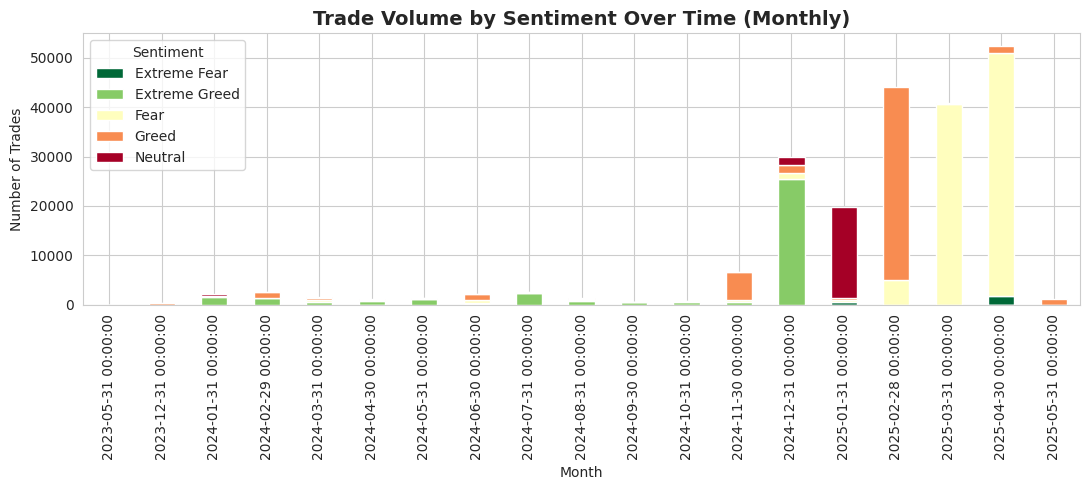

In [13]:
plt.figure(figsize=(11,5))
sentiment_counts = merged_df.groupby([pd.Grouper(key='date', freq='M'), 'classification']).size().unstack(fill_value=0)
sentiment_counts.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='RdYlGn_r')
plt.title('Trade Volume by Sentiment Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Number of Trades')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


,mean,median,sum,count
classification,,,,
Extreme Greed,85.046349,0.0,3.049592e+06,35858
Fear,42.770352,0.0,4.199920e+06,98197
Greed,41.073495,0.0,2.211602e+06,53845
Neutral,39.596363,0.0,8.314444e+05,20998
Extreme Fear,1.891632,0.0,4.399937e+03,2326


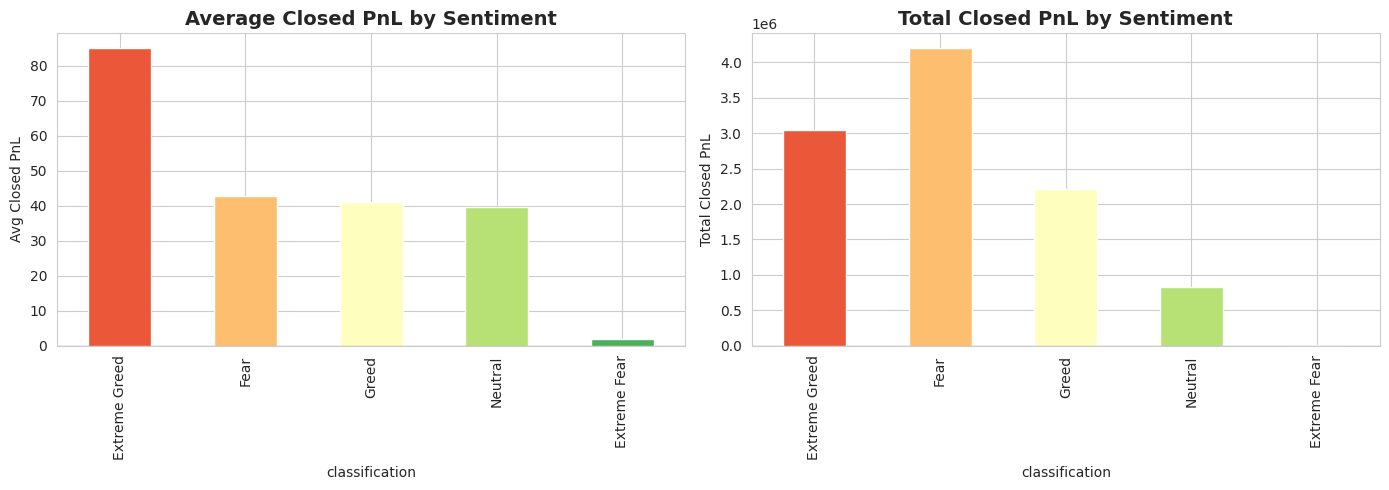

In [14]:
if pnl_col:
    pnl_by_sentiment = merged_df.groupby('classification')[pnl_col].agg(['mean', 'median', 'sum', 'count'])
    pnl_by_sentiment = pnl_by_sentiment.sort_values('mean', ascending=False)
    display(pnl_by_sentiment)

    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    pnl_by_sentiment['mean'].plot(kind='bar', ax=axes[0], color=sns.color_palette('RdYlGn', len(pnl_by_sentiment)))
    axes[0].set_title('Average Closed PnL by Sentiment')
    axes[0].set_ylabel('Avg Closed PnL')
    axes[0].axhline(0, color='black', linewidth=0.8)

    pnl_by_sentiment['sum'].plot(kind='bar', ax=axes[1], color=sns.color_palette('RdYlGn', len(pnl_by_sentiment)))
    axes[1].set_title('Total Closed PnL by Sentiment')
    axes[1].set_ylabel('Total Closed PnL')
    axes[1].axhline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()
else:
    print('closedPnL column not found — please check trader_df.columns and update pnl_col manually.')


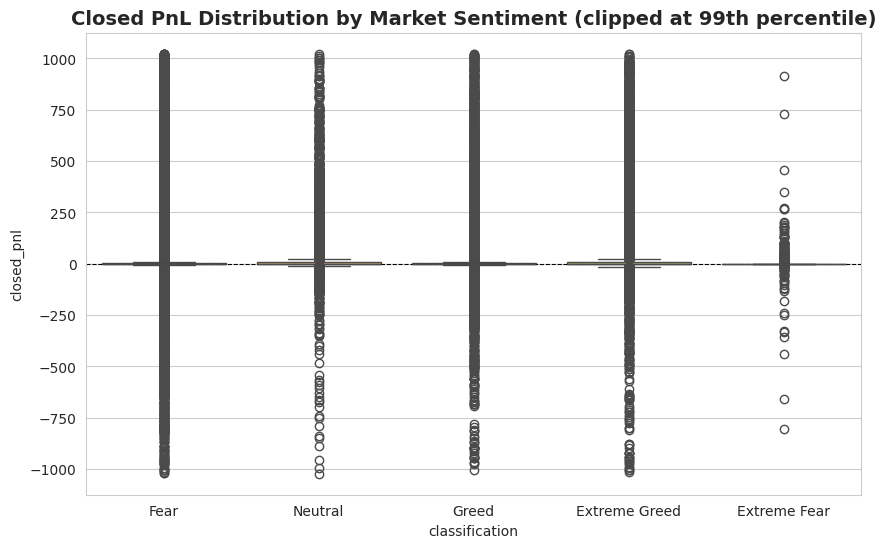

In [15]:
if pnl_col:
    plt.figure(figsize=(10,6))
    clip_val = merged_df[pnl_col].quantile(0.99)
    plot_df = merged_df[merged_df[pnl_col].abs() <= clip_val]
    sns.boxplot(data=plot_df, x='classification', y=pnl_col, palette='RdYlGn')
    plt.title('Closed PnL Distribution by Market Sentiment (clipped at 99th percentile)')
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.show()


,is_win
classification,
Extreme Greed,45.443137
Neutral,44.832841
Greed,39.875569
Fear,39.724228
Extreme Fear,29.277730


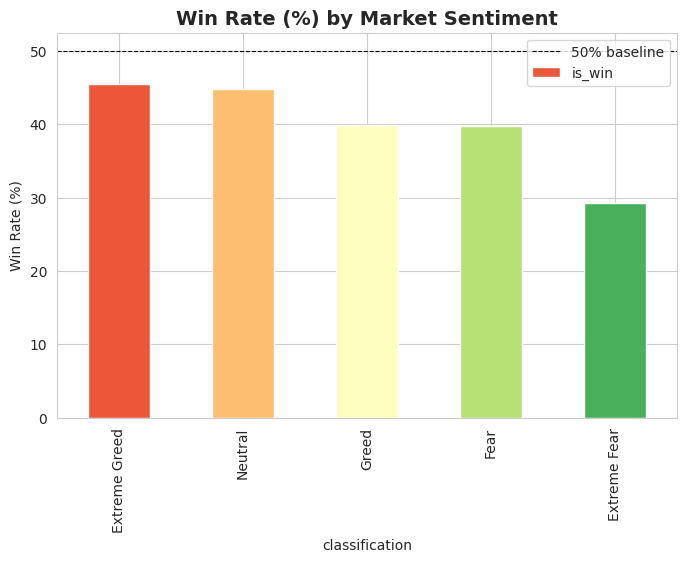

In [16]:
if pnl_col:
    merged_df['is_win'] = merged_df[pnl_col] > 0
    win_rate = merged_df.groupby('classification')['is_win'].mean().sort_values(ascending=False) * 100
    display(win_rate)

    plt.figure(figsize=(8,5))
    win_rate.plot(kind='bar', color=sns.color_palette('RdYlGn', len(win_rate)))
    plt.title('Win Rate (%) by Market Sentiment')
    plt.ylabel('Win Rate (%)')
    plt.axhline(50, color='black', linewidth=0.8, linestyle='--', label='50% baseline')
    plt.legend()
    plt.show()


In [17]:
if leverage_col:
    lev_by_sentiment = merged_df.groupby('classification')[leverage_col].agg(['mean', 'median', 'max'])
    display(lev_by_sentiment)

    plt.figure(figsize=(8,5))
    sns.boxplot(data=merged_df, x='classification', y=leverage_col, palette='RdYlGn')
    plt.title('Leverage Usage by Market Sentiment')
    plt.show()
else:
    print('Leverage column not found.')


Leverage column not found.


,mean,median,sum
classification,,,
Extreme Fear,2460.043834,50.00,5.722062e+06
Extreme Greed,5077.295049,32.00,1.820616e+08
Fear,2723.556121,31.78,2.674450e+08
Greed,7938.365875,25.14,4.274413e+08
Neutral,4471.644226,70.00,9.389559e+07


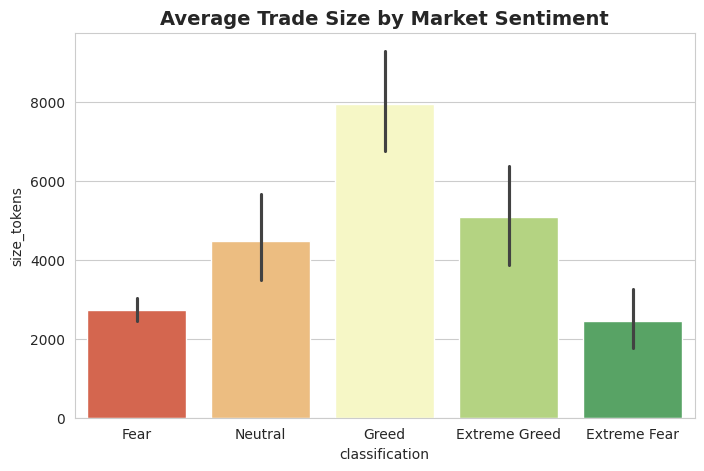

In [18]:
if size_col:
    size_by_sentiment = merged_df.groupby('classification')[size_col].agg(['mean', 'median', 'sum'])
    display(size_by_sentiment)

    plt.figure(figsize=(8,5))
    sns.barplot(data=merged_df, x='classification', y=size_col, estimator=np.mean, palette='RdYlGn')
    plt.title('Average Trade Size by Market Sentiment')
    plt.show()


side_clean,BUY,SELL
classification,,
Extreme Fear,50.214961,49.785039
Extreme Greed,43.594177,56.405823
Fear,49.186839,50.813161
Greed,52.329836,47.670164
Neutral,44.856653,55.143347


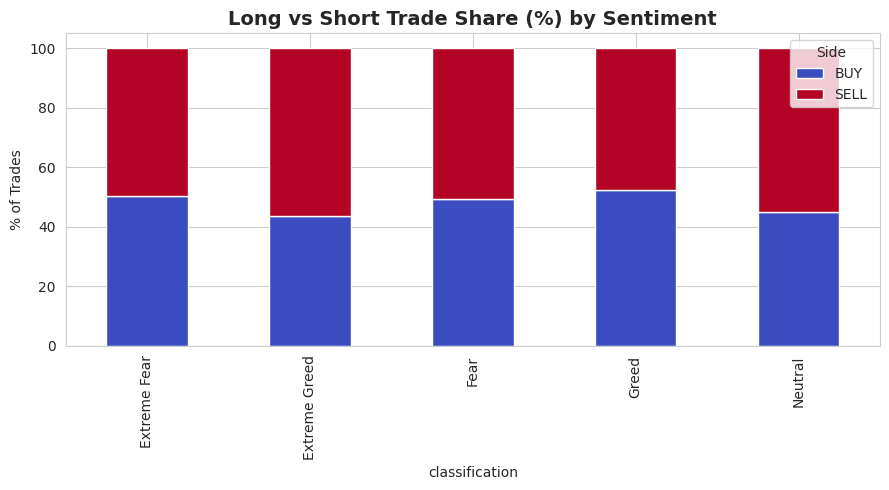

In [19]:
if side_col:
    side_sentiment = pd.crosstab(merged_df['classification'], merged_df['side_clean'], normalize='index') * 100
    display(side_sentiment)

    side_sentiment.plot(kind='bar', stacked=True, figsize=(9,5), colormap='coolwarm')
    plt.title('Long vs Short Trade Share (%) by Sentiment')
    plt.ylabel('% of Trades')
    plt.legend(title='Side')
    plt.tight_layout()
    plt.show()


In [20]:
if symbol_col:
    top_symbols = (merged_df.groupby(['classification', symbol_col]).size()
                   .reset_index(name='trade_count')
                   .sort_values(['classification', 'trade_count'], ascending=[True, False]))
    for cls in merged_df['classification'].unique():
        print(f"\nTop symbols during '{cls}' sentiment:")
        display(top_symbols[top_symbols['classification'] == cls].head(5))



Top symbols during 'Fear' sentiment:


,classification,coin,trade_count
319,Fear,HYPE,38490
299,Fear,BTC,16021
368,Fear,SOL,7752
252,Fear,@107,7057
308,Fear,ETH,4147



Top symbols during 'Neutral' sentiment:


,classification,coin,trade_count
567,Neutral,@107,3228
624,Neutral,HYPE,2990
601,Neutral,BTC,2220
612,Neutral,FARTCOIN,1277
662,Neutral,SOL,715



Top symbols during 'Greed' sentiment:


,classification,coin,trade_count
486,Greed,HYPE,19866
403,Greed,@107,7369
458,Greed,BTC,5508
471,Greed,ETH,3475
534,Greed,SOL,1906



Top symbols during 'Extreme Greed' sentiment:


,classification,coin,trade_count
79,Extreme Greed,@107,12271
181,Extreme Greed,HYPE,5349
167,Extreme Greed,ETH,2836
153,Extreme Greed,BTC,2170
212,Extreme Greed,PURR/USDC,1251



Top symbols during 'Extreme Fear' sentiment:


,classification,coin,trade_count
37,Extreme Fear,HYPE,1310
28,Extreme Fear,ETH,166
21,Extreme Fear,BTC,145
57,Extreme Fear,SOL,101
0,Extreme Fear,@107,67


In [21]:
if pnl_col and account_col:
    account_sentiment_pnl = (merged_df.groupby([account_col, 'classification'])[pnl_col]
                              .mean().unstack())
    display(account_sentiment_pnl.dropna(how='all').head(10))

    active_accounts = merged_df.groupby('classification')[account_col].nunique().sort_values(ascending=False)
    print("\nUnique active accounts by sentiment:")
    display(active_accounts)


classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
account,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,NaN,0.000000,663.733474,120.551794,216.303419
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.000000,30.411536,1.865842,1.951031,38.879537
0x271b280974205ca63b716753467d5a371de622ab,NaN,-0.200000,-19.012464,358.632043,NaN
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,2.598012,29.800897,-2.081407,8.012229,4.049892
0x2c229d22b100a7beb69122eed721cee9b24011dd,6.158762,76.250939,23.889538,43.741042,71.960603
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,NaN,-43.650301,-103.741689,253.530507,-854.055217
0x39cef799f8b69da1995852eea189df24eb5cae3c,0.000000,339.120554,-3.075660,-213.488065,-116.813036
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,NaN,490.975969,42.974770,91.524704,924.939318
0x420ab45e0bd8863569a5efbb9c05d91f40624641,NaN,185.086995,965.279074,0.000000,0.000000



Unique active accounts by sentiment:


,account
classification,
Fear,32
Greed,31
Extreme Greed,31
Neutral,26
Extreme Fear,20


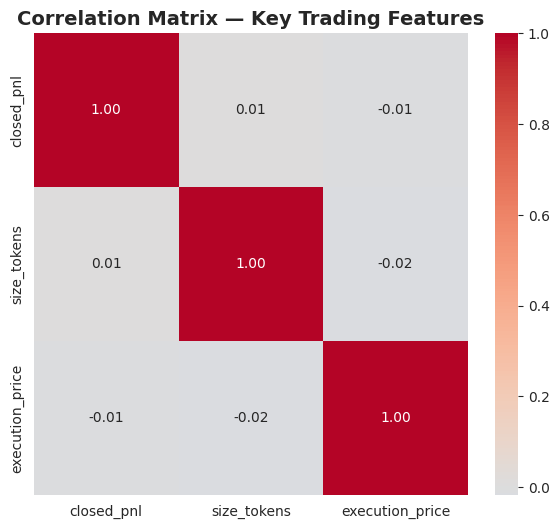

In [22]:
numeric_cols = [c for c in [pnl_col, size_col, leverage_col, price_col] if c]
if len(numeric_cols) > 1:
    corr = merged_df[numeric_cols].corr()
    plt.figure(figsize=(7,6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlation Matrix — Key Trading Features')
    plt.show()


In [23]:
if pnl_col:
    fear_labels = [c for c in merged_df['classification'].unique() if 'fear' in c.lower()]
    greed_labels = [c for c in merged_df['classification'].unique() if 'greed' in c.lower()]

    if fear_labels and greed_labels:
        fear_pnl = merged_df[merged_df['classification'].isin(fear_labels)][pnl_col].dropna()
        greed_pnl = merged_df[merged_df['classification'].isin(greed_labels)][pnl_col].dropna()

        stat, p_value = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
        print(f"Fear days  -> n={len(fear_pnl)}, mean PnL={fear_pnl.mean():.4f}")
        print(f"Greed days -> n={len(greed_pnl)}, mean PnL={greed_pnl.mean():.4f}")
        print(f"\nMann-Whitney U statistic: {stat:.2f}")
        print(f"p-value: {p_value:.5f}")
        if p_value < 0.05:
            print("=> Statistically significant difference in PnL between Fear and Greed regimes (p < 0.05).")
        else:
            print("=> No statistically significant difference detected (p >= 0.05).")
    else:
        print("Could not isolate clear Fear/Greed labels — check merged_df['classification'].unique()")


Fear days  -> n=100523, mean PnL=41.8245
Greed days -> n=89703, mean PnL=58.6513

Mann-Whitney U statistic: 4293616454.00
p-value: 0.00000
=> Statistically significant difference in PnL between Fear and Greed regimes (p < 0.05).


In [25]:
n1, n2 = 100523, 89703
U = 4293616454.00
r_effect = 1 - (2 * U) / (n1 * n2)
print(f"Rank-biserial effect size: {r_effect:.4f}")

print(merged_df.groupby('classification')[pnl_col].median())

Rank-biserial effect size: 0.0477
classification
Extreme Fear     0.0
Extreme Greed    0.0
Fear             0.0
Greed            0.0
Neutral          0.0
Name: closed_pnl, dtype: float64


In [26]:
closed_trades = merged_df[merged_df[pnl_col] != 0]
print(closed_trades.groupby('classification')[pnl_col].agg(['mean','median','count']))
print(closed_trades.groupby('classification')['is_win'].mean() * 100)

                      mean    median  count
classification                             
Extreme Fear      5.346217  1.332027    823
Extreme Greed   160.310781  9.353041  19023
Fear             85.703913  4.883000  49005
Greed            88.375718  5.938230  25025
Neutral          78.944590  8.584777  10532
classification
Extreme Fear     82.746051
Extreme Greed    85.659465
Fear             79.600041
Greed            85.798202
Neutral          89.384732
Name: is_win, dtype: float64


Conclusion

1. Sentiment and Trader Performance (Closed Trades Only)
After isolating actual position closes (closed_pnl != 0), a clear pattern emerges across the five sentiment regimes. Win rate is relatively stable across all regimes (79.6%–89.4%), indicating sentiment has limited influence on whether a given trade is profitable. The larger differentiator is the magnitude of PnL: Extreme Greed trades show the highest average PnL (160.31), while Extreme Fear trades show a sharply lower average (5.35) and median (1.33) — roughly 15–30x smaller than every other regime.
2. Extreme Fear: Caution, Not Collapse
Contrary to an earlier hypothesis that Extreme Fear would show a depressed win rate consistent with "catching falling knives," the data shows the opposite: Extreme Fear's win rate (82.75%) is comparable to or higher than Fear (79.60%) and close to Greed/Extreme Greed. What differs is trade size — the low mean and median PnL suggest traders scale down position size or exit more conservatively during acute fear, rather than losing more often. This regime also has the smallest sample (n=823), so this pattern should be treated as directional rather than conclusive.
3. Practical Implications

Extreme Greed shows the largest average gains per closed trade but the widest skew between mean and median, implying returns are concentrated in a subset of large wins rather than being broadly typical.
Extreme Fear does not show elevated risk of loss — it shows reduced trade magnitude, consistent with defensive position sizing already occurring naturally in this trader population, rather than reckless behavior.
A sentiment-aware strategy built on this data should focus less on "avoid trading during Fear" and more on understanding why position sizing shrinks in Extreme Fear — and whether that's leverage-driven caution or something else.